
# Plot Cross-Validation Summaries for Multiple Experiments

This notebook:
- Loads multiple `summary_mean_std.json` files (each summarizing mean±std across folds for one experiment).
- Builds a tidy DataFrame across experiments.
- Plots **bar charts with error bars** (mean ± std) for each metric.
- Exports a combined CSV and a paper-ready **LaTeX table**.

> **How to use**: Edit the dictionary in **Cell 2** to point to your experiments.


In [13]:

# === Cell 1: Imports & setup ===
import os, json, re
from pathlib import Path
from typing import Dict, Any, List, Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# rendering setup
%matplotlib inline

# output directory for generated files (plots, CSV, LaTeX table)
OUT_DIR = Path('./plots_out')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Saving outputs to:', OUT_DIR.resolve())

# Load classification results
df = pd.read_csv("./results/final_recognition_results.csv")

colors = {'MTRSAP': 'skyblue', 'MSTCN++': 'salmon', 'TCN': 'lightgreen'}


Saving outputs to: /sfs/gpfs/tardis/home/cjh9fw/Desktop/2025/DataCollectionSystem/benchmarks/gesture_recognition/MTRSAP/plots_out


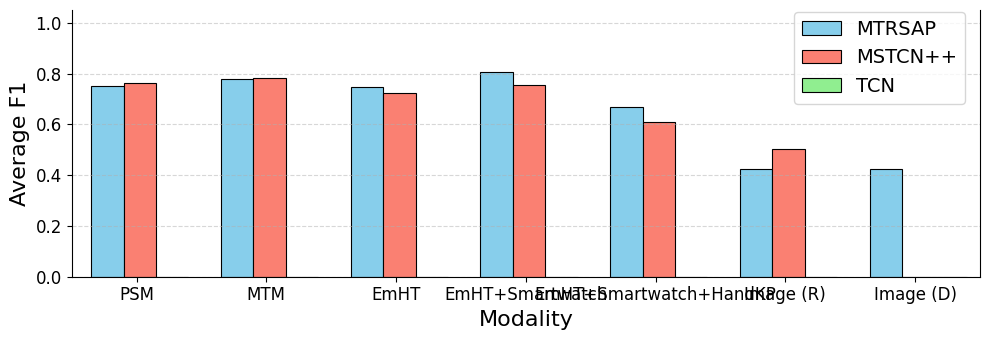

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


ignore_modalities_list = ['Console K','Console K (without grasper)']

ignore_model = 'TCN'

metric_of_interest = 'average_f1'

models = df['model'].unique()

df = df[~df['modality'].isin(ignore_modalities_list)]
df = df[df['model'] != ignore_model]

modalities_abbrev = df['modality'].unique()
x = np.arange(len(modalities_abbrev))

bar_width = 0.25
edge_width = 0.8


fig, ax = plt.subplots(figsize=(10, 3.5))


# Store bar containers for annotation
bar_containers = {}

for i, model in enumerate(models):
    model_data = df[df['model'] == model]
    values = [model_data[model_data['modality'] == mod][metric_of_interest].values[0] 
              if mod in model_data['modality'].values else 0 
              for mod in modalities_abbrev]
    
    offset = bar_width * (i - 0.5)
    bars = ax.bar(x + offset, values, width=bar_width, label=model, 
                 color=colors[model], edgecolor='black', linewidth=edge_width)
    bar_containers[model] = (bars, values, offset)

# Add star annotations for key observations
# Define key modalities to highlight
highlights = {
    # 'MTM': {'model': 'MTRSAP', 'label': 'Best\nPerformer', 'color': 'darkblue'},
    'EmHT+SW': {'model': 'MTRSAP', 'label': 'Promising\nMultimodal', 'color': 'darkgreen'}
}

for mod_abbrev, highlight_info in highlights.items():
    if mod_abbrev in modalities_abbrev:
        mod_idx = list(modalities_abbrev).index(mod_abbrev)
        model = highlight_info['model']
        
        if model in bar_containers:
            bars, values, offset = bar_containers[model]
            bar_height = values[mod_idx]
            
            # Add star above the bar
            ax.text(mod_idx + offset, bar_height + 0.01, '★', 
                   ha='center', va='bottom', fontsize=20, 
                   color=highlight_info['color'], fontweight='bold')
            
            # Add annotation text
            ax.text(mod_idx + offset, bar_height + 0.12, highlight_info['label'], 
                   ha='center', va='bottom', fontsize=11,
                   color=highlight_info['color'], fontweight='bold')

metric_label = metric_of_interest.replace('_', ' ').title()
ax.set_ylabel(metric_label, fontsize=16)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_ylim(0, 1.05)  # Increased to accommodate annotations

ax.set_xlabel('Modality', fontsize=16)
ax.set_xticks(x)
# Get current tick positions
xticks = ax.get_xticks()
# Shift them slightly (e.g., 0.1 units to the right)
ax.set_xticks(xticks + 0.1)

# Then set the labels
ax.set_xticklabels(modalities_abbrev, rotation=0, fontsize=12, ha='center')
ax.spines['top'].set_visible(False)
ax.set_xlim(-0.4, len(x) - 0.4)

fig.legend(loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=14)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


# both datasets side by side

Raven modalities: ['PSM', 'MTM', 'EmHT', 'EmHT+Smartwatch', 'Image (R)', 'Image (D)']
daVinci modalities: ['EmHT', 'Image (R)', 'Image (D)', 'EmHT+Image (R)', 'EmHT+Image (D)']
Saved: plots_out/raven_vs_davinci_models_by_modality_f1_muted.png


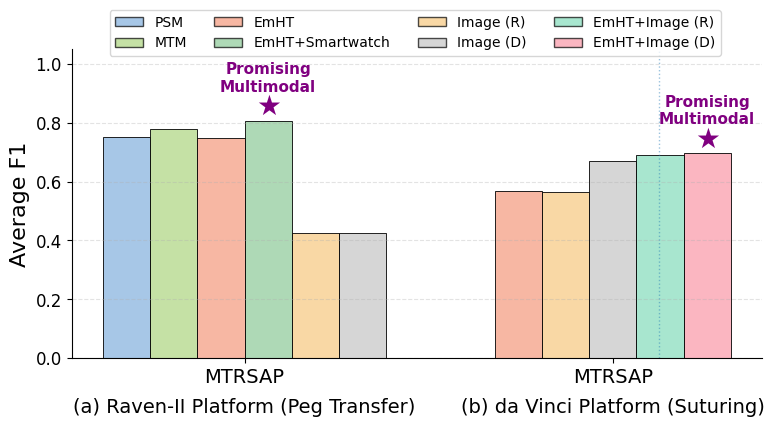

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# figure size
width, height = 8, 4.5

# ------------ config ------------
raven_csv   = './results/final_recognition_results.csv'
davinci_csv = './results/davinci_final_recognition_results.csv'
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

metric = 'average_f1'
ignore_models = ['TCN', 'MSTCN++', 'MS-TCN++']   # both spellings covered
ignore_modalities = {'EmHT+Smartwatch+HandKP'}

# ------------ helpers ------------
def normalize_series(s: pd.Series) -> pd.Series:
    """Remove non-alphanumerics so 'MS-TCN++' == 'MSTCN' 'MS TCN' etc."""
    return s.astype(str).str.replace(r'[^A-Za-z0-9]+', '', regex=True)

def pivot_scores(df, models, modalities, metric):
    p = df.pivot_table(index='model', columns='modality', values=metric, aggfunc='first')
    p = p.reindex(index=models, columns=modalities).fillna(0.0)
    return p

# ------------ load & filter ------------
raven   = pd.read_csv(raven_csv)
davinci = pd.read_csv(davinci_csv)

# normalize model names for robust ignoring
norm_ignore = set(normalize_series(pd.Series(ignore_models)).tolist())

raven   = raven[~normalize_series(raven['model']).isin(norm_ignore)]
davinci = davinci[~normalize_series(davinci['model']).isin(norm_ignore)]

raven   = raven[~raven['modality'].isin(ignore_modalities)].copy()
davinci = davinci[~davinci['modality'].isin(ignore_modalities)].copy()

# model order (as-appearing after filtering)
raven_models   = list(raven['model'].unique())
davinci_models = list(davinci['model'].unique())

# NEW: per-section modality lists (only what actually exists)
raven_modalities   = list(raven['modality'].unique())
davinci_modalities = list(davinci['modality'].unique())

print("Raven modalities:", raven_modalities)
print("daVinci modalities:", davinci_modalities)

unified_modalities = list(dict.fromkeys(list(raven_modalities) + list(davinci_modalities)))

# pivots
raven_p   = pivot_scores(raven,   raven_models,   unified_modalities, metric)
davinci_p = pivot_scores(davinci, davinci_models, unified_modalities, metric)

# ------------ aesthetics ------------
# muted, consistent colors for modalities

color_map = {
    "PSM": "#A7C7E7",                      # pastel blue
    "MTM": "#C5E1A5",                      # pastel green
    "EmHT": "#F7B7A3",                     # pastel coral
    "EmHT+Smartwatch": "#AED9B6",          # mint green
    "EmHT+Smartwatch+HandKP": "#D5B8E7",   # lavender
    "Image (R)": "#F9D8A5",                # light peach
    "Image (D)": "#D6D6D6",                # light gray
    "Image (DinoV2)": "#B3E5FC",           # baby blue
    "Image (R50)": "#FFDCA8",              # pastel apricot
    "EmHT+Image (R)": "#A8E6CF",           # seafoam
    "EmHT+Image (D)": "#FBB6C1",           # light pink
    "EmHT+Image (R50)": "#C4E7C2",         # pastel sage
    "EmHT+Image (DinoV2)": "#D1B3E0",      # soft purple
    "EmHT+SW": "#CBE8C8",                  # pale mint
    "EmHT+SW+HandKP": "#FFE2A8",           # buttery yellow
}



n_mod = max(1, len(unified_modalities))
bar_width  = min(0.22, 0.82 / n_mod)  # tighten if many modalities
edge_width = 0.6
section_pad = -0.2                     # space between Raven & daVinci sections

# x positions
x_raven   = np.arange(len(raven_models))
x_davinci = np.arange(len(davinci_models)) + (len(x_raven) + section_pad)

# ------------ plotting ------------
fig, ax = plt.subplots(figsize=(width, height))

def draw_grouped(ax, base_x, models, pivot_df, modalities, add_handles=False):
    n_mod_local = max(1, len(modalities))                     # FIX: section-specific count
    offsets = (np.arange(n_mod_local) - (n_mod_local - 1)/2) * bar_width  # FIX
    handles, labels = [], []
    for j, mod in enumerate(modalities):
        vals = pivot_df[mod].to_numpy() if mod in pivot_df.columns else np.zeros(len(models))
        bars = ax.bar(base_x + offsets[j], vals, width=bar_width,
                      color=color_map[mod], edgecolor=(0,0,0,1), linewidth=edge_width)
        if add_handles:
            handles.append(bars)
            labels.append(mod)
    return handles, labels


# draw sections
# draw sections (legend only once; placement unchanged)
handles, labels = draw_grouped(ax, x_raven,   raven_models,   raven_p,   raven_modalities,   add_handles=True)
draw_grouped(     ax, x_davinci, davinci_models, davinci_p, davinci_modalities, add_handles=False)

# y-axis
ax.set_ylabel('Average F1', fontsize=16)
ax.set_ylim(0, 1.05)
ax.yaxis.grid(True, linestyle='--', alpha=0.35)
# increase y axis tick font size
ax.tick_params(axis='y', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# x ticks (models)
xticks = np.concatenate([x_raven, x_davinci])
xtick_labels = raven_models + davinci_models
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, fontsize=14)

# section separator + labels
sep_x = len(x_raven) + (section_pad / 2.0)
ax.axvline(x=sep_x, linestyle=':', linewidth=1.0, alpha=0.45)

if len(x_raven):
    ax.text(x_raven.mean(), -0.20, '(a) Raven-II Platform (Peg Transfer)', ha='center', va='bottom', fontsize=14)
if len(x_davinci):
    ax.text(x_davinci.mean(), -0.20, '(b) da Vinci Platform (Suturing)', ha='center', va='bottom', fontsize=14)

import matplotlib.patches as mpatches
legend_modalities = unified_modalities  # already filtered & ordered from both sections
legend_handles = [
    mpatches.Patch(facecolor=color_map[m], edgecolor=(0,0,0,0.7), label=m)
    for m in legend_modalities
]
ax.legend(handles=legend_handles, labels=legend_modalities,
          loc='upper right', bbox_to_anchor=(0.95, 1.15),
          frameon=True, fontsize=10, title_fontsize=11,
          ncol=4)



# ---------- HIGHLIGHT ANNOTATIONS (paste after the two draw_grouped calls) ----------
highlights = {
    # example:
    # 'MTM': {'model': 'MTRSAP', 'label': 'Best\nPerformer', 'color': 'darkblue'},
    'EmHT+Smartwatch': {'model': 'MTRSAP', 'label': 'Promising\nMultimodal', 'color': 'purple'},
    'EmHT+Image (D)': {'model': 'MTRSAP', 'label': 'Promising\nMultimodal', 'color': 'purple'}
}

def _annotate_section(ax, base_x, models, modalities, pivot_df, highlights_dict):
    """Place star + label above the requested (model, modality) bars for this section."""
    if not len(models) or not len(modalities):
        return
    # Recompute the SAME offsets used for bars in this section
    n_mod_local = max(1, len(modalities))
    offsets = (np.arange(n_mod_local) - (n_mod_local - 1)/2.0) * bar_width

    mod_to_idx   = {m: j for j, m in enumerate(modalities)}
    model_to_idx = {m: i for i, m in enumerate(models)}

    for mod_abbrev, info in highlights_dict.items():
        mdl = info['model']
        if (mod_abbrev in mod_to_idx) and (mdl in model_to_idx):
            j = mod_to_idx[mod_abbrev]
            i = model_to_idx[mdl]
            x = base_x[i] + offsets[j]

            # Get the bar height from the pivot (0.0 if missing)
            y = 0.0
            if (mdl in pivot_df.index) and (mod_abbrev in pivot_df.columns):
                val = pivot_df.loc[mdl, mod_abbrev]
                y = float(val) if pd.notna(val) else 0.0

            if y > 0.0:
                # Star
                ax.text(x, y  , '★',
                        ha='center', va='bottom', fontsize=20,
                        color=info['color'], fontweight='bold')
                # Label
                ax.text(x, y + 0.09, info['label'],
                        ha='center', va='bottom', fontsize=11,
                        color=info['color'], fontweight='bold')

# Annotate Raven and daVinci sections independently (only where the bar actually exists)
_annotate_section(ax, x_raven,   raven_models,   raven_modalities,   raven_p,   highlights)
_annotate_section(ax, x_davinci, davinci_models, davinci_modalities, davinci_p, highlights)
# ---------- END HIGHLIGHT ANNOTATIONS ----------


plt.tight_layout()
out_path = f'{OUT_DIR}/raven_vs_davinci_models_by_modality_f1_muted.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()


# Confusion Matrix

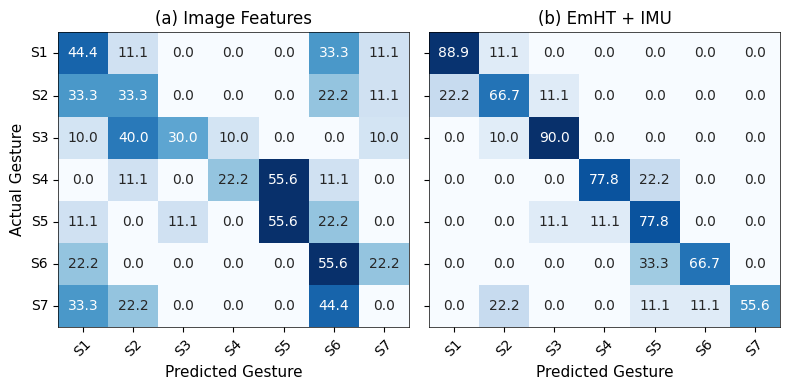

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Input paths ---
confusion_matrix_csv_img = './results/job_MTRSAP_4942196/images_10hz/fold_0/confusion_matrix_labeled_epoch_final.csv'
confusion_matrix_csv_trakstar_imu = './results/job_MTRSAP_4942747/trakstar_sw_left_sw_right_10hz/fold_0/confusion_matrix_labeled_epoch_final.csv'

# --- Class mapping ---
class_mapping = {
    "Approach peg" : "S1",
    "Align & grasp" : "S2",
    "Lift peg" : "S3",
    "Transfer peg - Get together" : "S4",
    "Transfer peg - Exchange" : "S5",
    "Approach pole" : "S6",
    "Align & place" : "S7"
}

# --- Load and normalize confusion matrices ---
def load_confusion_matrix(csv_path, mapping):
    df = pd.read_csv(csv_path, index_col=0)
    df.rename(index=mapping, columns=mapping, inplace=True)
    df = df.div(df.sum(axis=1), axis=0) * 100  # normalize row-wise (%)
    return df

cm_img = load_confusion_matrix(confusion_matrix_csv_img, class_mapping)
cm_trak = load_confusion_matrix(confusion_matrix_csv_trakstar_imu, class_mapping)

# --- Plot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
# add borders


sns.heatmap(cm_img, annot=True, fmt='.1f', cmap='Blues', cbar=False,
            xticklabels=cm_img.columns, yticklabels=cm_img.index, ax=axes[0])
axes[0].set_title('(a) Image Features', fontsize=12)
axes[0].set_xlabel('Predicted Gesture', fontsize=11)
axes[0].set_ylabel('Actual Gesture', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

for spine in axes[0].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('black')

sns.heatmap(cm_trak, annot=True, fmt='.1f', cmap='Blues', cbar=False,
            xticklabels=cm_trak.columns, yticklabels=cm_trak.index, ax=axes[1])
axes[1].set_title('(b) EmHT + IMU', fontsize=12)
axes[1].set_xlabel('Predicted Gesture', fontsize=11)
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

for spine in axes[1].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('black')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/confusion_matrix_side_by_side.png', dpi=300)
plt.show()


## CF matrices 4x4 Raven and Bootcamp

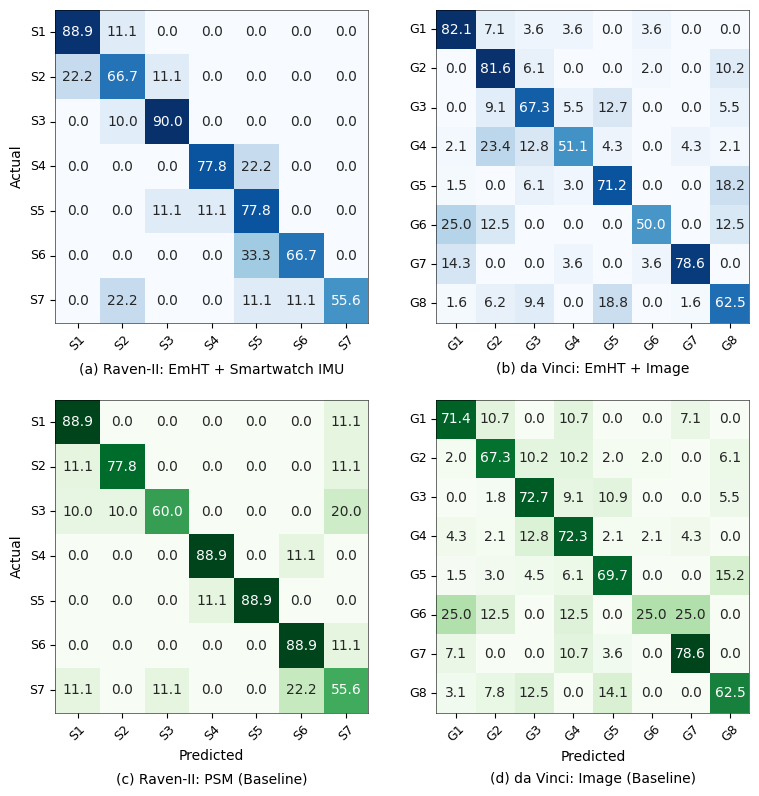

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Input paths for raven study ---
raven_confusion_matrix_csv_psm = './results/job_MTRSAP_4991210/raven_10hz/fold_0/confusion_matrix_labeled_epoch_final.csv'  # baseline for Raven
raven_confusion_matrix_csv_trakstar_imu = './results/job_MTRSAP_4942747/trakstar_sw_left_sw_right_10hz/fold_0/confusion_matrix_labeled_epoch_final.csv'

# --- Input paths for da Vinci bootcamp study ---
davinci_confusion_matrix_csv_image = './results/job_MTRSAP_4936858/images_30hz/fold_0/confusion_matrix_labeled_epoch_final.csv'  # baseline for da Vinci
davinci_confusion_matrix_csv_trakstar_img = './results/job_MTRSAP_4938139/trakstar_images_30hz/fold_0/confusion_matrix_labeled_epoch_final.csv'

# --- Class mappings ---
raven_class_mapping = {
    "Approach peg": "S1",
    "Align & grasp": "S2",
    "Lift peg": "S3",
    "Transfer peg - Get together": "S4",
    "Transfer peg - Exchange": "S5",
    "Approach pole": "S6",
    "Align & place": "S7",
}
davinci_class_mapping = {
    "Make C Loop": "G1",
    "Orient Needle": "G2",
    "Pull Needle out of Tissue": "G3",
    "Pull Suture": "G4",
    "Push Needle Through Tissue": "G5",
    "Reach Suture": "G6",
    "Square Knot and Cinch": "G7",
    "Target Needle": "G8",
}

def _canonicalize_labels(index_like, mapping):
    """Return a list mapping each label to its code (e.g., 'Orient Needle'->'G2').
       If it's already a code, keep as-is."""
    long2short = mapping
    short_set = set(mapping.values())
    out = []
    for lbl in index_like:
        if lbl in long2short:
            out.append(long2short[lbl])
        elif lbl in short_set:
            out.append(lbl)
        else:
            out.append(lbl)  # leave unknowns unchanged
    return out

def load_confusion_matrix(csv_path, mapping):
    df = pd.read_csv(csv_path, index_col=0)
    # Remap both index and columns to short codes, but preserve any already-short labels
    df.index = _canonicalize_labels(df.index, mapping)
    df.columns = _canonicalize_labels(df.columns, mapping)

    # Normalize row-wise (%)
    df = df.div(df.sum(axis=1), axis=0) * 100

    # Reorder to the mapping's value order, but only those present
    desired_order = [v for v in mapping.values() if v in df.index]
    df = df.reindex(index=desired_order, columns=desired_order)
    return df

# --- Load ---
cm_raven_baseline = load_confusion_matrix(raven_confusion_matrix_csv_psm, raven_class_mapping)          # Raven baseline = PSM
cm_raven_other    = load_confusion_matrix(raven_confusion_matrix_csv_trakstar_imu, raven_class_mapping)

cm_dv_baseline    = load_confusion_matrix(davinci_confusion_matrix_csv_image, davinci_class_mapping)    # da Vinci baseline = Image
cm_dv_other       = load_confusion_matrix(davinci_confusion_matrix_csv_trakstar_img, davinci_class_mapping)

# --- Plot (2x2): top = other, bottom = baselines ---
sns.reset_orig()

fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=False, sharey=False)

plots = [
    (cm_raven_other,    "(a) Raven-II: EmHT + Smartwatch IMU",         axes[0, 0], "Blues",   False),
    (cm_dv_other,       "(b) da Vinci: EmHT + Image",    axes[0, 1], "Blues",   False),
    (cm_raven_baseline, "(c) Raven-II: PSM (Baseline)",       axes[1, 0], "Greens", True),
    (cm_dv_baseline,    "(d) da Vinci: Image (Baseline)",  axes[1, 1], "Greens",  True),
]

for df, title, ax, cmap, is_baseline in plots:
    # subtle panel tint for baselines
    if is_baseline:
        ax.set_facecolor("#f6f2e8")  # light warm tint to highlight

    sns.heatmap(
        df, annot=True, fmt='.1f', cmap=cmap, cbar=False,
        xticklabels=df.columns, yticklabels=df.index, ax=ax,
        square=True
    )
    # ax.set_title(title, fontsize=10, pad=6)
    if not is_baseline:
        ax.text(0.5, -0.125, title, ha='center', va='top', transform=ax.transAxes, fontsize=10)
    else:
        ax.text(0.5, -0.19, title, ha='center', va='top', transform=ax.transAxes, fontsize=10)

    # Left column gets y-label
    ax.set_ylabel('Actual', fontsize=10) if ax in (axes[0,0], axes[1,0]) else ax.set_ylabel('')
    # Bottom row gets x-label
    ax.set_xlabel('Predicted', fontsize=10) if ax in (axes[1,0], axes[1,1]) else ax.set_xlabel('')

    ax.tick_params(axis='x', labelrotation=45, labelsize=9)
    ax.tick_params(axis='y', labelrotation=0,  labelsize=9)

    # Thin border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.4)
        spine.set_color('black')

plt.tight_layout(w_pad=0.8, h_pad=2)
plt.savefig(f'{OUT_DIR}/confusion_matrix_2x2_small.png', dpi=300)
plt.show()


## Plot for visualizing per class f1 and class counts

{'train_class_stats': {'S1': 29, 'S2': 29, 'S3': 30, 'S4': 31, 'S5': 30, 'S6': 28, 'S7': 27}, 'val_class_stats': {'S1': 7, 'S2': 8, 'S3': 8, 'S4': 8, 'S5': 7, 'S6': 7, 'S7': 7}, 'test_class_stats': {'S1': 9, 'S2': 9, 'S3': 10, 'S4': 9, 'S5': 9, 'S6': 9, 'S7': 9}}


/tmp/ipykernel_13802/4212468269.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class_Name', y='F1-Score', data=metrics_df, ax=ax1, palette='pastel', edgecolor='black')


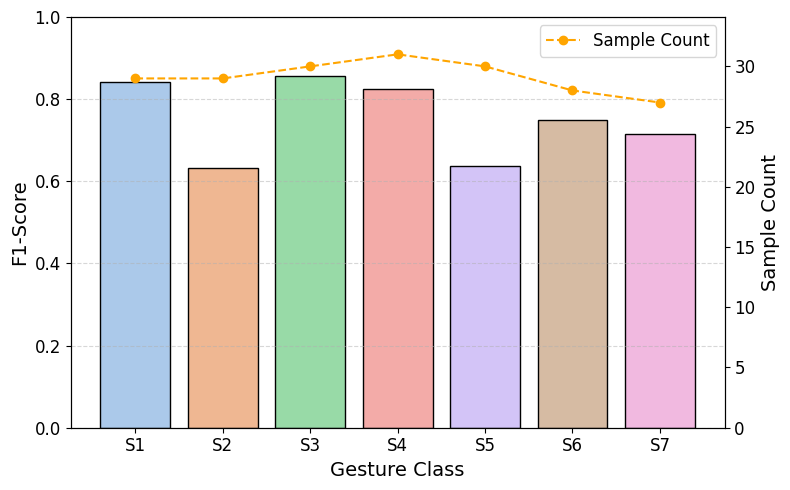

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

per_class_stats = './results/job_MTRSAP_4942747/trakstar_sw_left_sw_right_10hz/fold_0/class_metrics_epoch_final.csv' # columns : Class_ID,Class_Name,Accuracy,Precision,Recall,F1-Score,Support
class_counts = './results/job_MTRSAP_4942747/trakstar_sw_left_sw_right_10hz/fold_0/0_class_stats.json' # contains number of samples in train , val and test sets per class

# --- Class mapping ---
class_mapping = {
    "Approach peg" : "S1",
    "Align & grasp" : "S2",
    "Lift peg" : "S3",
    "Transfer peg - Get together" : "S4",
    "Transfer peg - Exchange" : "S5",
    "Approach pole" : "S6",
    "Align & place" : "S7"
}

# --- Load per-class metrics ---
metrics_df = pd.read_csv(per_class_stats)
metrics_df['Class_Name'] = metrics_df['Class_Name'].map(class_mapping)

# --- Load class counts ---
with open(class_counts, 'r') as f:
    counts_data = json.load(f)

print(counts_data)
train_counts = counts_data['train_class_stats']
val_counts = counts_data['val_class_stats']
test_counts = counts_data['test_class_stats']

# reset seaborn to fonts to default
sns.reset_orig()

# plot f1 score per class with counts on secondary y-axis
fig, ax1 = plt.subplots(figsize=(8, 5))
sns.barplot(x='Class_Name', y='F1-Score', data=metrics_df, ax=ax1, palette='pastel', edgecolor='black')
ax1.set_ylabel('F1-Score', fontsize=14)
ax1.set_xlabel('Gesture Class', fontsize=14)
ax1.set_ylim(0, 1)
ax1.tick_params(axis='y', labelsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
# Secondary y-axis for counts
ax2 = ax1.twinx()
ax2.plot(metrics_df['Class_Name'], metrics_df['Class_Name'].map(train_counts), color='orange', marker='o', linestyle='--', label='Sample Count')
ax2.set_ylabel('Sample Count', fontsize=14)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, max(train_counts.values()) * 1.1)
ax2.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

   Class_ID Class_Name  Accuracy  Precision  Recall  F1-Score  Support
0         0          8    0.7143     0.6667  0.7143    0.6897       28
1         1         11    0.6735     0.7174  0.6735    0.6947       49
2         2         16    0.7273     0.6452  0.7273    0.6838       55
3         3         17    0.7234     0.6182  0.7234    0.6667       47
4         4         18    0.6970     0.7188  0.6970    0.7077       66
5         5         20    0.2500     0.5000  0.2500    0.3333        8
6         6         22    0.7857     0.7857  0.7857    0.7857       28
7         7         23    0.6250     0.7143  0.6250    0.6667       64
{'train_class_stats': {'8': 92, '11': 158, '16': 174, '17': 149, '18': 209, '20': 25, '22': 90, '23': 206}, 'val_class_stats': {'8': 23, '11': 39, '16': 44, '17': 37, '18': 53, '20': 6, '22': 23, '23': 51}, 'test_class_stats': {'8': 28, '11': 49, '16': 55, '17': 47, '18': 66, '20': 8, '22': 28, '23': 64}}


/tmp/ipykernel_13802/1617235800.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class_Name', y='F1-Score', data=metrics_df, ax=ax1, palette='pastel', edgecolor='black')


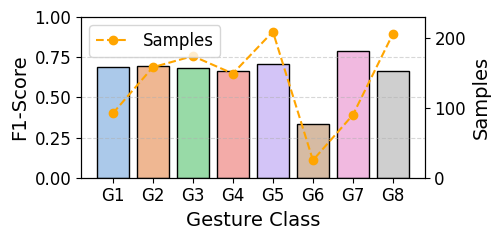

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
per_class_stats = './results/job_MTRSAP_4938139/trakstar_images_30hz/fold_0/class_metrics_epoch_final.csv' # columns : Class_ID,Class_Name,Accuracy,Precision,Recall,F1-Score,Support
class_counts = './results/job_MTRSAP_4938139/trakstar_images_30hz/fold_0/0_class_stats.json' # contains number of samples in train , val and test sets per class

per_class_stats = './results/job_MTRSAP_4936858/images_30hz/fold_0/class_metrics_epoch_final.csv' # columns : Class_ID,Class_Name,Accuracy,Precision,Recall,F1-Score,Support
class_counts = './results/job_MTRSAP_4936858/images_30hz/fold_0/0_class_stats.json' # contains number of samples in train , val and test sets per class


# --- Class mapping ---
class_mapping = {
    "Make C Loop" : "8",
    "Orient Needle" : "11",
    "Pull Needle out of Tissue" : "16",
    "Pull Suture" : "17",
    "Push Needle Through Tissue" : "18",
    "Reach Suture" : "20",
    "Square Knot and Cinch" : "22",
    "Target Needle" : "23"
}

new_mappping = {
    "8" : "G1",
    "11" : "G2",
    "16" : "G3",
    "17" : "G4",
    "18" : "G5",
    "20" : "G6",
    "22" : "G7",
    "23" : "G8"
}


# --- Load per-class metrics ---
metrics_df = pd.read_csv(per_class_stats)

# combine classes 16 and 17 and average their metrics so that they map to G6


metrics_df['Class_Name'] = metrics_df['Class_Name'].map(class_mapping)


print(metrics_df)

# --- Load class counts ---
with open(class_counts, 'r') as f:
    counts_data = json.load(f)

print(counts_data)
train_counts = counts_data['train_class_stats']
val_counts = counts_data['val_class_stats']
test_counts = counts_data['test_class_stats']

# map train_counts keys to new mapping
train_counts = {new_mappping[k]: v for k, v in train_counts.items()}
val_counts = {new_mappping[k]: v for k, v in val_counts.items()}
test_counts = {new_mappping[k]: v for k, v in test_counts.items()}

# map the Class_Name in metrics_df to new mapping
metrics_df['Class_Name'] = metrics_df['Class_Name'].map(new_mappping)
# reset seaborn to fonts to default
sns.reset_orig()

# plot f1 score per class with counts on secondary y-axis
fig, ax1 = plt.subplots(figsize=(5, 2.5))
sns.barplot(x='Class_Name', y='F1-Score', data=metrics_df, ax=ax1, palette='pastel', edgecolor='black')
ax1.set_ylabel('F1-Score', fontsize=14)
ax1.set_xlabel('Gesture Class', fontsize=14)
ax1.set_ylim(0, 1)
ax1.tick_params(axis='y', labelsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
# Secondary y-axis for counts
ax2 = ax1.twinx()
ax2.plot(metrics_df['Class_Name'], metrics_df['Class_Name'].map(train_counts), color='orange', marker='o', linestyle='--', label='Samples')
ax2.set_ylabel('Samples', fontsize=14)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, max(train_counts.values()) * 1.1)
ax2.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/per_class_f1_scores.png', dpi=300)
plt.show()

# save figure

# Per class figure for raven

   Class_ID Class_Name  Accuracy  Precision  Recall  F1-Score  Support
0         0         S1    0.1111     0.5000  0.1111    0.1818        9
1         1         S2    0.2222     1.0000  0.2222    0.3636        9
2         2         S3    0.8000     0.5714  0.8000    0.6667       10
3         3         S4    0.7778     0.6364  0.7778    0.7000        9
4         4         S5    0.2222     0.4000  0.2222    0.2857        9
5         5         S6    0.6667     0.6667  0.6667    0.6667        9
6         6         S7    0.7778     0.3333  0.7778    0.4667        9
{'train_class_stats': {'S1': 29, 'S2': 29, 'S3': 30, 'S4': 31, 'S5': 30, 'S6': 28, 'S7': 27}, 'val_class_stats': {'S1': 7, 'S2': 8, 'S3': 8, 'S4': 8, 'S5': 7, 'S6': 7, 'S7': 7}, 'test_class_stats': {'S1': 9, 'S2': 9, 'S3': 10, 'S4': 9, 'S5': 9, 'S6': 9, 'S7': 9}}


/tmp/ipykernel_13802/2806253881.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class_Name', y='F1-Score', data=metrics_df, ax=ax1, palette='pastel', edgecolor='black')


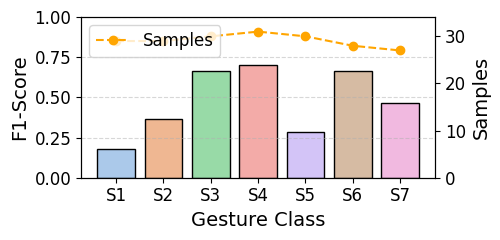

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
per_class_stats = './results/job_MTRSAP_4938749/trakstar_sw_left_sw_right_images_10hz/fold_0/class_metrics_epoch_final.csv' # columns : Class_ID,Class_Name,Accuracy,Precision,Recall,F1-Score,Support
class_counts = './results/job_MTRSAP_4938749/trakstar_sw_left_sw_right_images_10hz/fold_0/0_class_stats.json' # contains number of samples in train , val and test sets per class


    # S1: Approach peg
    # S2: Align & grasp
    # S3: Lift peg
    # S4: Transfer peg - Get together
    # S5: Transfer peg - Exchange
    # S6: Approach pole
    # S7: Align & place

# --- Class mapping ---
class_mapping = {
    "Approach peg" : "S1",
    "Align & grasp" : "S2",
    "Lift peg" : "S3",
    "Transfer peg - Get together" : "S4",
    "Transfer peg - Exchange" : "S5",
    "Approach pole" : "S6",
    "Align & place" : "S7"
}

# invert mapping to get long names from short codes
new_mappping = {
    "S1" : "S1",
    "S2" : "S2",
    "S3" : "S3",
    "S4" : "S4",
    "S5" : "S5",
    "S6" : "S6",
    "S7" : "S7"
}



# --- Load per-class metrics ---
metrics_df = pd.read_csv(per_class_stats)

# combine classes 16 and 17 and average their metrics so that they map to G6


metrics_df['Class_Name'] = metrics_df['Class_Name'].map(class_mapping)


print(metrics_df)

# --- Load class counts ---
with open(class_counts, 'r') as f:
    counts_data = json.load(f)

print(counts_data)
train_counts = counts_data['train_class_stats']
val_counts = counts_data['val_class_stats']
test_counts = counts_data['test_class_stats']

# map train_counts keys to new mapping
train_counts = {new_mappping[k]: v for k, v in train_counts.items()}
val_counts = {new_mappping[k]: v for k, v in val_counts.items()}
test_counts = {new_mappping[k]: v for k, v in test_counts.items()}

# map the Class_Name in metrics_df to new mapping
# reset seaborn to fonts to default
sns.reset_orig()

# plot f1 score per class with counts on secondary y-axis
fig, ax1 = plt.subplots(figsize=(5, 2.5))
sns.barplot(x='Class_Name', y='F1-Score', data=metrics_df, ax=ax1, palette='pastel', edgecolor='black')
ax1.set_ylabel('F1-Score', fontsize=14)
ax1.set_xlabel('Gesture Class', fontsize=14)
ax1.set_ylim(0, 1)
ax1.tick_params(axis='y', labelsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
# Secondary y-axis for counts
ax2 = ax1.twinx()
ax2.plot(metrics_df['Class_Name'], metrics_df['Class_Name'].map(train_counts), color='orange', marker='o', linestyle='--', label='Samples')
ax2.set_ylabel('Samples', fontsize=14)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, max(train_counts.values()) * 1.1)
ax2.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/per_class_f1_scores.png', dpi=300)
plt.show()

# save figure